# Why Our Validation Metric Lied: A Calibration Analysis

**Phase 2 finding:** 4 of 5 submitted LightGBM variants improved local validation WRMSSE but produced worse Kaggle private LB scores.  
This notebook documents the data behind that reversal and traces it to two compounding causes.

*Data sourced from `reports/leaderboard.md`. No large CSV files required.*

## The Reversal

The ShelfSense pipeline uses a single 28-day holdout (days 1,914-1,941: **April 25 - May 22, 2016**) as the validation window. Six LightGBM variants were trained, evaluated on this window, and submitted to Kaggle. The result was a consistent pattern: variants that looked better locally either failed to improve the private leaderboard or made it worse.

This is not a model bug or a data leak. It is a structural problem with single-window validation: one 28-day holdout is insufficient to distinguish genuine improvements from overfits to that specific month's demand pattern.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

In [2]:
# Scores sourced from reports/leaderboard.md
# val_wrmsse: in-model holdout (d_1886-d_1913, March 28 - April 24 2016)
# private_lb: Kaggle private leaderboard (d_1942-d_1969, May 23 - June 19 2016)
variants = pd.DataFrame([
    {'name': 'tvp_13',     'val_wrmsse': 0.6860, 'private_lb': 0.5693},
    {'name': 'ylags',      'val_wrmsse': 0.6830, 'private_lb': 0.5749},
    {'name': 'store_dept', 'val_wrmsse': 0.6294, 'private_lb': 0.5882},
    {'name': 'per_dept',   'val_wrmsse': 0.7333, 'private_lb': 0.6137},
    {'name': 'rmse_mh',    'val_wrmsse': 0.6699, 'private_lb': 0.6205},
    {'name': 'per_store',  'val_wrmsse': 0.6140, 'private_lb': 0.6410},
])

baseline = variants[variants['name'] == 'tvp_13'].iloc[0]
variants['val_delta'] = variants['val_wrmsse'] - baseline['val_wrmsse']
variants['priv_delta'] = variants['private_lb'] - baseline['private_lb']

print(variants[['name', 'val_wrmsse', 'private_lb', 'val_delta', 'priv_delta']].to_string(index=False))

      name  val_wrmsse  private_lb  val_delta  priv_delta
    tvp_13      0.6860      0.5693     0.0000      0.0000
     ylags      0.6830      0.5749    -0.0030      0.0056
store_dept      0.6294      0.5882    -0.0566      0.0189
  per_dept      0.7333      0.6137     0.0473      0.0444
   rmse_mh      0.6699      0.6205    -0.0161      0.0512
 per_store      0.6140      0.6410    -0.0720      0.0717


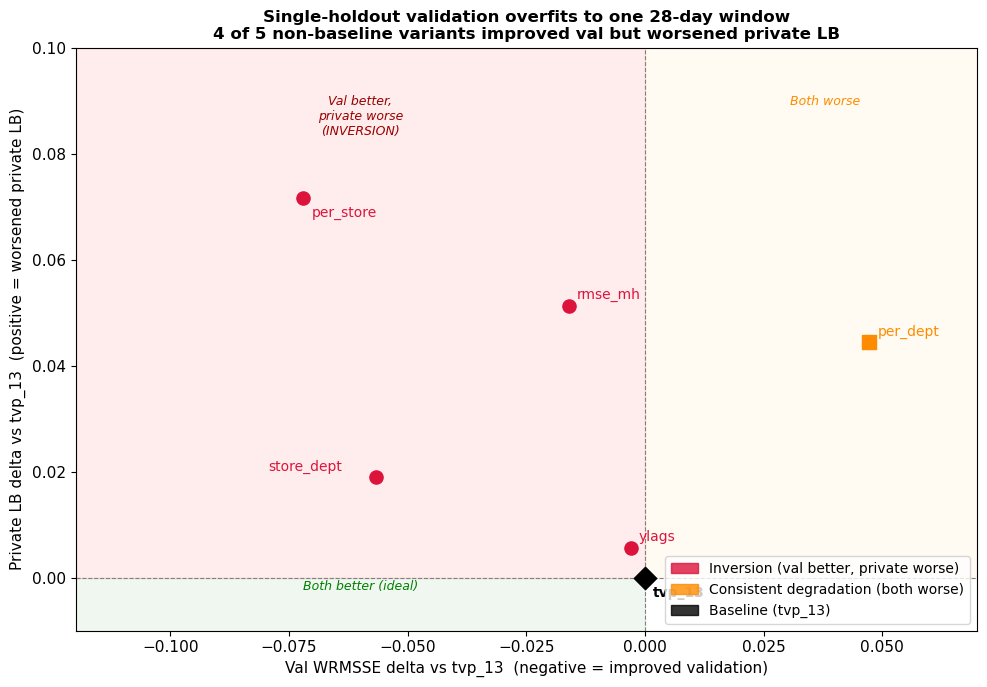

Inversions (val better, private worse): 4 of 5 non-baseline variants


In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

# Quadrant shading
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.fill_between([-0.12, 0], [0.1, 0.1], 0, alpha=0.07, color='red')
ax.fill_between([0, 0.07], [0.1, 0.1], 0, alpha=0.05, color='orange')
ax.fill_between([-0.12, 0], [0, 0], [-0.01, -0.01], alpha=0.06, color='green')

# Quadrant labels
ax.text(-0.06, 0.091, 'Val better,\nprivate worse\n(INVERSION)',
        ha='center', va='top', fontsize=9, color='#990000', style='italic')
ax.text(0.038, 0.091, 'Both worse',
        ha='center', va='top', fontsize=9, color='darkorange', style='italic')
ax.text(-0.06, -0.003, 'Both better (ideal)',
        ha='center', va='bottom', fontsize=9, color='green', style='italic')

# Label offsets to avoid overlap
offsets = {
    'tvp_13':     (6, -14),
    'ylags':      (6, 5),
    'store_dept': (-78, 5),
    'per_dept':   (6, 5),
    'rmse_mh':    (6, 5),
    'per_store':  (6, -14),
}

for _, row in variants.iterrows():
    is_base = row['name'] == 'tvp_13'
    is_inv  = (row['val_delta'] < 0) and (row['priv_delta'] > 0) and not is_base
    color  = 'black' if is_base else ('crimson' if is_inv else 'darkorange')
    marker = 'D' if is_base else ('o' if is_inv else 's')
    size   = 130 if is_base else 90
    ax.scatter(row['val_delta'], row['priv_delta'],
               color=color, marker=marker, s=size, zorder=5)
    dx, dy = offsets.get(row['name'], (6, 5))
    ax.annotate(row['name'], (row['val_delta'], row['priv_delta']),
                xytext=(dx, dy), textcoords='offset points', fontsize=10,
                fontweight='bold' if is_base else 'normal', color=color)

ax.set_xlabel('Val WRMSSE delta vs tvp_13  (negative = improved validation)', fontsize=11)
ax.set_ylabel('Private LB delta vs tvp_13  (positive = worsened private LB)', fontsize=11)
ax.set_title(
    'Single-holdout validation overfits to one 28-day window\n'
    '4 of 5 non-baseline variants improved val but worsened private LB',
    fontsize=12, fontweight='bold')

legend_handles = [
    mpatches.Patch(color='crimson',    alpha=0.8, label='Inversion (val better, private worse)'),
    mpatches.Patch(color='darkorange', alpha=0.8, label='Consistent degradation (both worse)'),
    mpatches.Patch(color='black',      alpha=0.8, label='Baseline (tvp_13)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10)
ax.set_xlim(-0.12, 0.07)
ax.set_ylim(-0.01, 0.1)
plt.tight_layout()
plt.show()

n_inv = int(((variants['val_delta'] < 0) & (variants['priv_delta'] > 0)
             & (variants['name'] != 'tvp_13')).sum())
print(f'Inversions (val better, private worse): {n_inv} of {len(variants)-1} non-baseline variants')

In [4]:
non_baseline = variants[variants['name'] != 'tvp_13'].copy()

r_p, p_p = stats.pearsonr(non_baseline['val_delta'], non_baseline['priv_delta'])
r_s, p_s = stats.spearmanr(non_baseline['val_delta'], non_baseline['priv_delta'])
print('All 5 non-baseline variants (tvp_17 excluded: no Kaggle submission made):')
print(f'  Pearson  r = {r_p:.3f}  (p = {p_p:.3f})')
print(f'  Spearman r = {r_s:.3f}  (p = {p_s:.3f})')
print()

inversions = non_baseline[
    (non_baseline['val_delta'] < 0) & (non_baseline['priv_delta'] > 0)
]
print(f'Inversion cases ({len(inversions)} variants): val better, private worse')
for _, row in inversions.sort_values('val_delta').iterrows():
    print(f"  {row['name']:12s}: val_delta={row['val_delta']:+.4f}  "
          f"priv_delta={row['priv_delta']:+.4f}")
print()

if len(inversions) >= 3:
    r_inv, p_inv = stats.pearsonr(inversions['val_delta'].abs(), inversions['priv_delta'])
    print(f'Among inversions: |val improvement| vs private regression:')
    print(f'  Pearson r = {r_inv:.3f}  (p = {p_inv:.3f})')
    print(f'  Larger val improvements do not reliably predict larger private regressions.')
    print(f'  rmse_mh improved val by only 0.016 but caused the second-worst private'
          f' degradation (+0.051): objective-metric mismatch compounds the window problem.')

All 5 non-baseline variants (tvp_17 excluded: no Kaggle submission made):
  Pearson  r = -0.226  (p = 0.714)
  Spearman r = -0.500  (p = 0.391)

Inversion cases (4 variants): val better, private worse
  per_store   : val_delta=-0.0720  priv_delta=+0.0717
  store_dept  : val_delta=-0.0566  priv_delta=+0.0189
  rmse_mh     : val_delta=-0.0161  priv_delta=+0.0512
  ylags       : val_delta=-0.0030  priv_delta=+0.0056

Among inversions: |val improvement| vs private regression:
  Pearson r = 0.553  (p = 0.447)
  Larger val improvements do not reliably predict larger private regressions.
  rmse_mh improved val by only 0.016 but caused the second-worst private degradation (+0.051): objective-metric mismatch compounds the window problem.


## Two Compounding Mechanisms

### 1. Single-window holdout overfitting

The validation window (April 25 - May 22, 2016) is one specific 28-day period with its own SNAP calendar, event mix, and seasonal demand level. Optuna runs that minimise WRMSSE on this window find parameters that are optimal for *this particular month*, not for the general demand distribution. `store_dept` ran 10 Optuna trials per slice (700 total across 70 slices) — those parameters are tuned to April-May 2016. The private evaluation window (May-Jun 2016) has a different pattern, and the over-tuned parameters do not transfer.

The next cell shows a concrete symptom: the validation window has an unusually **low zero rate** relative to the training period. Lower zero rate means more active demand — easier to forecast and easier to overfit to.

### 2. Objective-metric mismatch for `rmse_mh`

The RMSE variant trains on mean squared error. WRMSSE weights high-revenue and intermittent series more heavily than MSE does. In the validation window (atypically low zero rate, more active demand), MSE and WRMSSE happen to correlate better — so the RMSE model looks good. In the private window, zero-inflation reasserts, and the model's systematic under-forecasting of sparse series drives WRMSSE up sharply. **Using the evaluation metric as the training objective is non-negotiable for M5.**

*Full analysis: [docs/MODELS.md — Val-Private Divergence](../docs/MODELS.md)*

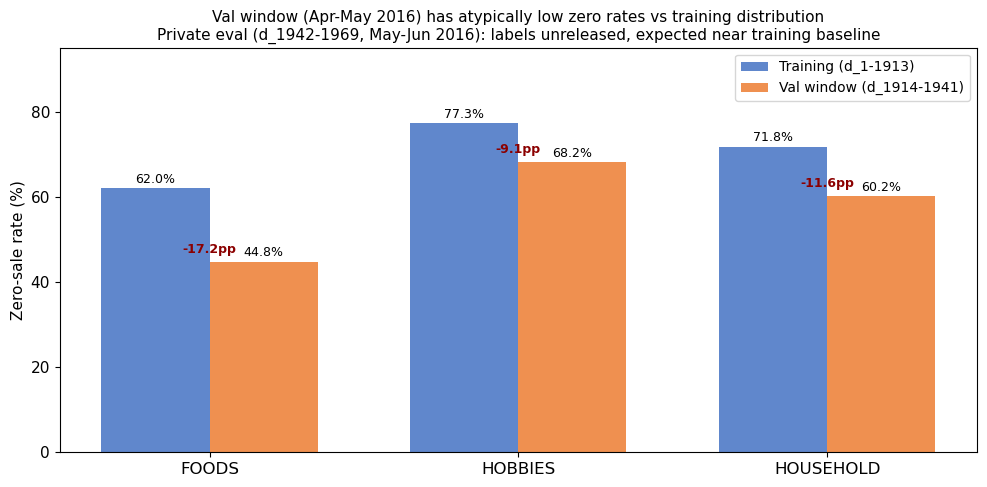

Overall zero-rate delta (training vs val window): -13.8 pp
The val window is 13.8 pp more active than the long-run average.
Models tuned to this window overestimate their own accuracy.


In [5]:
# Zero rates computed from sales_train_evaluation.csv
# Training (d_1-d_1913, Jan 2011-Apr 2016) vs val window (d_1914-d_1941, Apr-May 2016)
# Derivation: see notebooks/01_eda.ipynb, Section 3.2
zero_rates = {
    'FOODS':     {'Training\n(d_1-1913)': 62.0, 'Val window\n(d_1914-1941)': 44.8},
    'HOBBIES':   {'Training\n(d_1-1913)': 77.3, 'Val window\n(d_1914-1941)': 68.2},
    'HOUSEHOLD': {'Training\n(d_1-1913)': 71.8, 'Val window\n(d_1914-1941)': 60.2},
}

cats    = list(zero_rates.keys())
windows = ['Training\n(d_1-1913)', 'Val window\n(d_1914-1941)']
colors  = ['#4472C4', '#ED7D31']
x       = np.arange(len(cats))
width   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (window, color) in enumerate(zip(windows, colors)):
    vals = [zero_rates[cat][window] for cat in cats]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=window.replace('\n', ' '), color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=12)
ax.set_ylabel('Zero-sale rate (%)')
ax.set_ylim(0, 95)
ax.set_title(
    'Val window (Apr-May 2016) has atypically low zero rates vs training distribution\n'
    'Private eval (d_1942-1969, May-Jun 2016): labels unreleased, expected near training baseline',
    fontsize=11)
ax.legend(fontsize=10)

# Annotate the delta for each category
for i, cat in enumerate(cats):
    delta = (zero_rates[cat]['Training\n(d_1-1913)']
             - zero_rates[cat]['Val window\n(d_1914-1941)'])
    mid_x = x[i]
    mid_y = zero_rates[cat]['Val window\n(d_1914-1941)'] + 2
    ax.annotate(f'-{delta:.1f}pp', xy=(mid_x, mid_y),
                ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

overall_delta = 68.2 - 54.4
print(f'Overall zero-rate delta (training vs val window): -{overall_delta:.1f} pp')
print('The val window is 13.8 pp more active than the long-run average.')
print('Models tuned to this window overestimate their own accuracy.')

## What This Taught Me

**The val window is an optimistic outlier.** April-May 2016 has 13.8 percentage points lower zero rate than the overall training period. Every model evaluated against this window sees artificially good metrics -- and every Optuna run tuned against it finds parameters that are optimal for an atypically active month, not the general demand distribution.

**Four inversions, one direction.** Of the five non-baseline variants with confirmed Kaggle scores, four (ylags, store_dept, rmse_mh, per_store) improved validation WRMSSE and worsened private LB. The fifth (per_dept) degraded both. The ideal quadrant -- val better AND private better -- is empty.

**The fix is walk-forward cross-validation.** Five rolling 28-day folds across the last 140 days of training data would average out the April-May anomaly. A variant that consistently improves WRMSSE across all five folds -- covering different SNAP schedules, seasonal demand levels, and zero-rate regimes -- is a genuine improvement, not a lucky calibration to one atypical month.

The `cv_evaluation` Dagster asset specification is in [docs/MODELS.md -- Walk-Forward CV](../docs/MODELS.md#val-private-divergence). Implementing it is the highest-priority next step before running further model experiments.